In [ ]:
import torch
import torchaudio
from transformers import ClapModel, ClapProcessor  # Using Hugging Face's implementation

# 1. Load the pretrained CLAP model and processor.
# Here we use the popular LAION CLAP checkpoint "laion/clap-htsat-unfused"
model_name = "laion/clap-htsat-unfused"
model = ClapModel.from_pretrained(model_name)
processor = ClapProcessor.from_pretrained(model_name)

# 2. Load and preprocess your audio file.
audio_path = "path/to/your/audio.wav"
waveform, sample_rate = torchaudio.load(audio_path)
# The processor will handle preprocessing such as resampling if needed.
audio_inputs = processor(audios=waveform, sampling_rate=sample_rate, return_tensors="pt")

# 3. Encode the audio to obtain its embedding.
with torch.no_grad():
    # Note: Depending on the implementation, you may use model.get_audio_features() instead.
    audio_embedding = model.get_audio_features(**audio_inputs)
    # If necessary, squeeze out extra dimensions.
    audio_embedding = audio_embedding.squeeze(0)

# 4. Define candidate sentiment labels and get their text embeddings.
sentiment_labels = ["positive sentiment", "neutral sentiment", "negative sentiment"]
# Process text inputs; the processor automatically tokenizes the text.
text_inputs = processor(text=sentiment_labels, return_tensors="pt", padding=True)
with torch.no_grad():
    # Again, depending on the API, you might use model.get_text_features().
    text_embeddings = model.get_text_features(**text_inputs)

# 5. Compute cosine similarity between the audio embedding and each text embedding.
cosine_similarities = torch.nn.functional.cosine_similarity(
    audio_embedding.unsqueeze(0), text_embeddings, dim=-1
)

# 6. Select the sentiment with the highest similarity score.
predicted_index = torch.argmax(cosine_similarities).item()
predicted_sentiment = sentiment_labels[predicted_index]
print("Predicted Sentiment:", predicted_sentiment)
#use below data set ,, from datasets import load_dataset

ds = load_dataset("DynamicSuperb/Sentiment_Analysis_SLUE-VoxCeleb"),,,,meta data for audio metadata
dataset_info:
  features:
    - name: audio
      dtype: audio
    - name: file
      dtype: string
    - name: instruction
      dtype: string
    - name: label
      dtype: string
  splits:
    - name: test
      num_bytes: 526994497.092
      num_examples: 3553
  download_size: 520689066
  dataset_size: 526994497.092
configs:
  - config_name: default
    data_files:
      - split: test
        path: data/test-*,,, and cassify accuracy using appropriate matrix 

In [1]:
import torch
import torchaudio
from transformers import ClapModel, ClapProcessor
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def load_clap_model(model_name="laion/clap-htsat-unfused"):
    """Load the CLAP model and processor."""
    model = ClapModel.from_pretrained(model_name)
    processor = ClapProcessor.from_pretrained(model_name)
    return model, processor

def get_audio_embedding(model, processor, audio_data, sampling_rate):
    """Get audio embeddings using CLAP."""
    audio_inputs = processor(audios=audio_data, sampling_rate=sampling_rate, return_tensors="pt")
    with torch.no_grad():
        audio_embedding = model.get_audio_features(**audio_inputs)
    return audio_embedding.squeeze(0)

def get_text_embeddings(model, processor, sentiment_labels):
    """Get text embeddings for sentiment labels."""
    text_inputs = processor(text=sentiment_labels, return_tensors="pt", padding=True)
    with torch.no_grad():
        text_embeddings = model.get_text_features(**text_inputs)
    return text_embeddings

def predict_sentiment(audio_embedding, text_embeddings, sentiment_labels):
    """Predict sentiment using cosine similarity."""
    cosine_similarities = torch.nn.functional.cosine_similarity(
        audio_embedding.unsqueeze(0), text_embeddings, dim=-1
    )
    predicted_index = torch.argmax(cosine_similarities).item()
    return sentiment_labels[predicted_index], predicted_index

def plot_confusion_matrix(y_true, y_pred, labels):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def main():
    # 1. Load model and dataset
    model, processor = load_clap_model()
    model.eval()
    
    # Load dataset
    dataset = load_dataset("DynamicSuperb/Sentiment_Analysis_SLUE-VoxCeleb")
    test_dataset = dataset["test"]
    
    # Define sentiment labels
    sentiment_labels = ["positive sentiment", "neutral sentiment", "negative sentiment"]
    
    # Get text embeddings for sentiment labels (only need to do this once)
    text_embeddings = get_text_embeddings(model, processor, sentiment_labels)
    
    # Lists to store true and predicted labels
    true_labels = []
    predicted_labels = []
    
    # 2. Process each audio file in the dataset
    for i, example in enumerate(test_dataset):
        try:
            # Get audio data
            audio_data = torch.tensor(example['audio']['array'])
            sampling_rate = example['audio']['sampling_rate']
            
            # Get audio embedding
            audio_embedding = get_audio_embedding(model, processor, audio_data, sampling_rate)
            
            # Predict sentiment
            predicted_sentiment, pred_idx = predict_sentiment(audio_embedding, text_embeddings, sentiment_labels)
            
            # Map dataset labels to our label indices
            true_label_map = {
                "positive": 0,
                "neutral": 1,
                "negative": 2
            }
            true_idx = true_label_map[example['label']]
            
            # Store true and predicted labels
            true_labels.append(true_idx)
            predicted_labels.append(pred_idx)
            
            if i % 100 == 0:
                print(f"Processed {i} examples...")
                
        except Exception as e:
            print(f"Error processing example {i}: {str(e)}")
            continue
    
    # 3. Calculate and display metrics
    print("\nClassification Report:")
    print(classification_report(true_labels, predicted_labels, 
                              target_names=sentiment_labels))
    
    # 4. Plot confusion matrix
    plot_confusion_matrix(true_labels, predicted_labels, sentiment_labels)

if __name__ == "__main__":
    main()

config.json:   0%|          | 0.00/5.39k [00:00<?, ?B/s]

C:\Users\Sumit\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sumit\.cache\huggingface\hub\models--laion--clap-htsat-unfused. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/615M [00:00<?, ?B/s]

Error while downloading from https://cdn-lfs.hf.co/repos/ee/a9/eea9aad8c745730c282ec26d588ae5476dfd0ed833a1828c25de61f515f62c84/1cd3c601bc4afe0fa87be3de4c13dd2cfadd249fac1e29acf74a9b296c3219bb?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27pytorch_model.bin%3B+filename%3D%22pytorch_model.bin%22%3B&response-content-type=application%2Foctet-stream&Expires=1740404145&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0MDQwNDE0NX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9yZXBvcy9lZS9hOS9lZWE5YWFkOGM3NDU3MzBjMjgyZWMyNmQ1ODhhZTU0NzZkZmQwZWQ4MzNhMTgyOGMyNWRlNjFmNTE1ZjYyYzg0LzFjZDNjNjAxYmM0YWZlMGZhODdiZTNkZTRjMTNkZDJjZmFkZDI0OWZhYzFlMjlhY2Y3NGE5YjI5NmMzMjE5YmI%7EcmVzcG9uc2UtY29udGVudC1kaXNwb3NpdGlvbj0qJnJlc3BvbnNlLWNvbnRlbnQtdHlwZT0qIn1dfQ__&Signature=qZWG7sWtiUyfJfyHPDfWn2IJY4Ac%7ENYdU-ZrmzPLMS9z3eE9EkAJEQtEbNovURw0FTUjAB-xjcPMkO8jT4AmN0Zbp4lcYplv9MWW7ON4BxuPOmGP1eeWGAdo1Y7t5RN9xiGpqLVJUzJN1G4aJ7exGLKA4g1HuPzkVehkh4SE5l6CkUS-Zj9s6Unh

pytorch_model.bin:  58%|#####8    | 357M/615M [00:00<?, ?B/s]

...

C:\Users\Sumit\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sumit\.cache\huggingface\hub\datasets--DynamicSuperb--Sentiment_Analysis_SLUE-VoxCeleb. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


test-00000-of-00002.parquet:   0%|          | 0.00/270M [00:00<?, ?B/s]

test-00001-of-00002.parquet:   0%|          | 0.00/251M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/3553 [00:00<?, ? examples/s]

ImportError: To support decoding audio files, please install 'librosa' and 'soundfile'.

In [ ]:
import torch
import torchaudio
from transformers import ClapModel, ClapProcessor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_clap_model(model_name="laion/clap-htsat-unfused"):
    """Load the CLAP model and processor."""
    model = ClapModel.from_pretrained(model_name)
    processor = ClapProcessor.from_pretrained(model_name)
    return model, processor

def get_audio_embedding(model, processor, audio_data, sampling_rate):
    """Get audio embeddings using CLAP."""
    # Ensure audio is the right shape and format
    if audio_data.dim() == 1:
        audio_data = audio_data.unsqueeze(0)
    
    # Convert to float and normalize if needed
    if audio_data.dtype != torch.float32:
        audio_data = audio_data.float()
    
    if audio_data.max() > 1.0:
        audio_data = audio_data / 32768.0  # Normalize 16-bit audio
    
    audio_inputs = processor(audios=audio_data.numpy(), sampling_rate=sampling_rate, return_tensors="pt")
    
    with torch.no_grad():
        audio_embedding = model.get_audio_features(**audio_inputs)
    
    return audio_embedding.squeeze(0)

def get_text_embeddings(model, processor, sentiment_labels):
    """Get text embeddings for sentiment labels."""
    text_inputs = processor(text=sentiment_labels, return_tensors="pt", padding=True)
    with torch.no_grad():
        text_embeddings = model.get_text_features(**text_inputs)
    return text_embeddings

def predict_sentiment(audio_embedding, text_embeddings, sentiment_labels):
    """Predict sentiment using cosine similarity."""
    cosine_similarities = torch.nn.functional.cosine_similarity(
        audio_embedding.unsqueeze(0), text_embeddings, dim=-1
    )
    
    # Get probabilities
    probabilities = torch.nn.functional.softmax(cosine_similarities, dim=0)
    
    predicted_index = torch.argmax(cosine_similarities).item()
    return sentiment_labels[predicted_index], predicted_index, probabilities.tolist()

def plot_sentiment_probabilities(probabilities, labels):
    """Plot sentiment probabilities as a bar chart."""
    plt.figure(figsize=(10, 6))
    colors = ['green', 'blue', 'red']
    
    bars = plt.bar(labels, probabilities, color=colors)
    
    # Add probability values on top of bars
    for bar, prob in zip(bars, probabilities):
        plt.text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.01, 
                 f'{prob:.2f}', 
                 ha='center', va='bottom')
    
    plt.title('Sentiment Probabilities')
    plt.ylabel('Probability')
    plt.ylim(0, max(probabilities) + 0.1)
    plt.tight_layout()
    plt.show()

def main(audio_path):
    # 1. Load model
    print("Loading CLAP model...")
    model, processor = load_clap_model()
    model.eval()
    
    # Define sentiment labels
    sentiment_labels = ["positive sentiment", "neutral sentiment", "negative sentiment"]
    
    # Get text embeddings for sentiment labels (only need to do this once)
    print("Computing text embeddings for sentiment labels...")
    text_embeddings = get_text_embeddings(model, processor, sentiment_labels)
    
    # 2. Load the audio file
    print(f"Loading audio from: {audio_path}")
    waveform, sample_rate = torchaudio.load(audio_path)
    audio_data = waveform[0]  # Use first channel if stereo
    
    # Print audio information
    duration = len(audio_data) / sample_rate
    print(f"Audio loaded: {duration:.2f} seconds, {sample_rate} Hz sample rate")
    
    # 3. Get audio embedding
    print("Computing audio embedding...")
    audio_embedding = get_audio_embedding(model, processor, audio_data, sample_rate)
    
    # 4. Predict sentiment
    print("Predicting sentiment...")
    predicted_sentiment, pred_idx, probabilities = predict_sentiment(
        audio_embedding, text_embeddings, sentiment_labels
    )
    
    # 5. Display results
    print("\n===== RESULTS =====")
    print(f"Predicted sentiment: {predicted_sentiment}")
    print("\nProbabilities:")
    for label, prob in zip(sentiment_labels, probabilities):
        print(f"  {label}: {prob:.4f}")
    
    # 6. Plot probabilities
    plot_sentiment_probabilities(probabilities, [label.split()[0] for label in sentiment_labels])

if __name__ == "__main__":
    import argparse
    
    parser = argparse.ArgumentParser(description="Zero-shot audio sentiment analysis using CLAP")
    parser.add_argument("audio_path", type=str, help="Path to the audio file")
    args = parser.parse_args()
    
    main(args.audio_path)

In [2]:
import torch
import torchaudio
from transformers import ClapModel, ClapProcessor
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_clap_model(model_name="laion/clap-htsat-unfused"):
    """Load the CLAP model and processor."""
    model = ClapModel.from_pretrained(model_name)
    processor = ClapProcessor.from_pretrained(model_name)
    return model, processor

def get_audio_embedding(model, processor, audio_data, sampling_rate):
    """Get audio embeddings using CLAP."""
    # Ensure audio is the right shape and format
    if audio_data.dim() == 1:
        audio_data = audio_data.unsqueeze(0)
    
    # Convert to float and normalize if needed
    if audio_data.dtype != torch.float32:
        audio_data = audio_data.float()
    
    if audio_data.max() > 1.0:
        audio_data = audio_data / 32768.0  # Normalize 16-bit audio
    
    audio_inputs = processor(audios=audio_data.numpy(), sampling_rate=sampling_rate, return_tensors="pt")
    
    with torch.no_grad():
        audio_embedding = model.get_audio_features(**audio_inputs)
    
    return audio_embedding.squeeze(0)

def get_text_embeddings(model, processor, sentiment_labels):
    """Get text embeddings for sentiment labels."""
    text_inputs = processor(text=sentiment_labels, return_tensors="pt", padding=True)
    with torch.no_grad():
        text_embeddings = model.get_text_features(**text_inputs)
    return text_embeddings

def predict_sentiment(audio_embedding, text_embeddings, sentiment_labels):
    """Predict sentiment using cosine similarity."""
    cosine_similarities = torch.nn.functional.cosine_similarity(
        audio_embedding.unsqueeze(0), text_embeddings, dim=-1
    )
    
    # Get probabilities
    probabilities = torch.nn.functional.softmax(cosine_similarities, dim=0)
    
    predicted_index = torch.argmax(cosine_similarities).item()
    return sentiment_labels[predicted_index], predicted_index, probabilities.tolist()

def plot_sentiment_probabilities(probabilities, labels):
    """Plot sentiment probabilities as a bar chart."""
    plt.figure(figsize=(10, 6))
    colors = ['green', 'blue', 'red']
    
    bars = plt.bar(labels, probabilities, color=colors)
    
    # Add probability values on top of bars
    for bar, prob in zip(bars, probabilities):
        plt.text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.01, 
                 f'{prob:.2f}', 
                 ha='center', va='bottom')
    
    plt.title('Sentiment Probabilities')
    plt.ylabel('Probability')
    plt.ylim(0, max(probabilities) + 0.1)
    plt.tight_layout()
    plt.show()

def main():
    # Your specific audio path
    audio_path = r"C:\Users\Sumit\Downloads\audio.wav"
    
    # 1. Load model
    print("Loading CLAP model...")
    model, processor = load_clap_model()
    model.eval()
    
    # Define sentiment labels
    sentiment_labels = ["positive sentiment", "neutral sentiment", "negative sentiment"]
    
    # Get text embeddings for sentiment labels (only need to do this once)
    print("Computing text embeddings for sentiment labels...")
    text_embeddings = get_text_embeddings(model, processor, sentiment_labels)
    
    # 2. Load the audio file
    print(f"Loading audio from: {audio_path}")
    waveform, sample_rate = torchaudio.load(audio_path)
    audio_data = waveform[0]  # Use first channel if stereo
    
    # Print audio information
    duration = len(audio_data) / sample_rate
    print(f"Audio loaded: {duration:.2f} seconds, {sample_rate} Hz sample rate")
    
    # 3. Get audio embedding
    print("Computing audio embedding...")
    audio_embedding = get_audio_embedding(model, processor, audio_data, sample_rate)
    
    # 4. Predict sentiment
    print("Predicting sentiment...")
    predicted_sentiment, pred_idx, probabilities = predict_sentiment(
        audio_embedding, text_embeddings, sentiment_labels
    )
    
    # 5. Display results
    print("\n===== RESULTS =====")
    print(f"Predicted sentiment: {predicted_sentiment}")
    print("\nProbabilities:")
    for label, prob in zip(sentiment_labels, probabilities):
        print(f"  {label}: {prob:.4f}")
    
    # 6. Plot probabilities
    plot_sentiment_probabilities(probabilities, [label.split()[0] for label in sentiment_labels])

if __name__ == "__main__":
    main()

Loading CLAP model...
Computing text embeddings for sentiment labels...
Loading audio from: C:\Users\Sumit\Downloads\audio.wav


RuntimeError: Couldn't find appropriate backend to handle uri C:\Users\Sumit\Downloads\audio.wav and format None.

In [8]:
import torch
from transformers import ClapModel, ClapProcessor
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os

def load_clap_model(model_name="laion/clap-htsat-unfused"):
    """Load the CLAP model and processor."""
    model = ClapModel.from_pretrained(model_name)
    processor = ClapProcessor.from_pretrained(model_name)
    return model, processor

def get_audio_embedding(model, processor, audio_data, sampling_rate):
    """Get audio embeddings using CLAP."""
    # Ensure audio is properly formatted for the processor
    # Convert numpy array to tensor if needed
    if isinstance(audio_data, np.ndarray):
        audio_data = torch.from_numpy(audio_data).float()
    
    # Ensure audio is the right shape
    if audio_data.dim() == 1:
        audio_data = audio_data.unsqueeze(0)
    
    # Make sure audio is float and normalized between -1 and 1
    if audio_data.dtype != torch.float32:
        audio_data = audio_data.float()
    
    if audio_data.max() > 1.0:
        audio_data = audio_data / audio_data.max()
    
    # Convert back to numpy for processor
    audio_np = audio_data.numpy()
    
    # Process the audio
    audio_inputs = processor(audios=audio_np, sampling_rate=sampling_rate, return_tensors="pt")
    
    # Get audio features
    with torch.no_grad():
        audio_embedding = model.get_audio_features(**audio_inputs)
    
    return audio_embedding.squeeze(0)

def get_text_embeddings(model, processor, sentiment_labels):
    """Get text embeddings for sentiment labels."""
    text_inputs = processor(text=sentiment_labels, return_tensors="pt", padding=True)
    with torch.no_grad():
        text_embeddings = model.get_text_features(**text_inputs)
    return text_embeddings

def predict_sentiment(audio_embedding, text_embeddings, sentiment_labels):
    """Predict sentiment using cosine similarity."""
    cosine_similarities = torch.nn.functional.cosine_similarity(
        audio_embedding.unsqueeze(0), text_embeddings, dim=-1
    )
    
    # Get probabilities
    probabilities = torch.nn.functional.softmax(cosine_similarities, dim=0)
    
    predicted_index = torch.argmax(cosine_similarities).item()
    return sentiment_labels[predicted_index], predicted_index, probabilities.tolist()

def plot_sentiment_probabilities(probabilities, labels):
    """Plot sentiment probabilities as a bar chart."""
    plt.figure(figsize=(10, 6))
    colors = ['green', 'blue', 'red']
    
    bars = plt.bar(labels, probabilities, color=colors)
    
    # Add probability values on top of bars
    for bar, prob in zip(bars, probabilities):
        plt.text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.01, 
                 f'{prob:.2f}', 
                 ha='center', va='bottom')
    
    plt.title('Sentiment Probabilities')
    plt.ylabel('Probability')
    plt.ylim(0, max(probabilities) + 0.1)
    plt.tight_layout()
    plt.show()

def main():
    # Your specific audio path
    audio_path = r"C:\Users\Sumit\Downloads\audio.wav"
    
    # Check if file exists
    if not os.path.exists(audio_path):
        print(f"Error: File '{audio_path}' does not exist!")
        return
        
    # 1. Load model
    print("Loading CLAP model...")
    model, processor = load_clap_model()
    model.eval()
    
    # Define sentiment labels
    sentiment_labels = ["positive sentiment", "neutral sentiment", "negative sentiment"]
    
    # Get text embeddings for sentiment labels (only need to do this once)
    print("Computing text embeddings for sentiment labels...")
    text_embeddings = get_text_embeddings(model, processor, sentiment_labels)
    
    # 2. Load the audio file using librosa
    print(f"Loading audio from: {audio_path}")
    try:
        audio_data, sample_rate = librosa.load(audio_path, sr=None)
        print(f"Audio loaded: {librosa.get_duration(y=audio_data, sr=sample_rate):.2f} seconds, {sample_rate} Hz sample rate")
    except Exception as e:
        print(f"Error loading audio file: {str(e)}")
        print("Try installing ffmpeg: pip install ffmpeg-python")
        return
    
    # 3. Get audio embedding
    print("Computing audio embedding...")
    audio_embedding = get_audio_embedding(model, processor, audio_data, sample_rate)
    
    # 4. Predict sentiment
    print("Predicting sentiment...")
    predicted_sentiment, pred_idx, probabilities = predict_sentiment(
        audio_embedding, text_embeddings, sentiment_labels
    )
    
    # 5. Display results
    print("\n===== RESULTS =====")
    print(f"Predicted sentiment: {predicted_sentiment}")
    print("\nProbabilities:")
    for label, prob in zip(sentiment_labels, probabilities):
        print(f"  {label}: {prob:.4f}")
    
    # 6. Plot probabilities
    plot_sentiment_probabilities(probabilities, [label.split()[0] for label in sentiment_labels])

if __name__ == "__main__":
    main()

Loading CLAP model...
Computing text embeddings for sentiment labels...
Loading audio from: C:\Users\Sumit\Downloads\audio.wav
Audio loaded: 8.78 seconds, 44100 Hz sample rate
Computing audio embedding...


ValueError: The model corresponding to this feature extractor: ClapFeatureExtractor was trained using a sampling rate of 48000. Please make sure that the provided `raw_speech` input was sampled with 48000 and not 44100.

In [6]:
!pip install librosa

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 4.4 MB/s eta 0:00:00


Loading CLAP model...
Required sampling rate for CLAP model: 48000 Hz
Computing text embeddings for sentiment labels...
Loading audio from: C:\Users\Sumit\Downloads\audio.wav
Original audio: 8.78 seconds, 44100 Hz
Resampling audio from 44100 Hz to 48000 Hz
Resampled audio: 8.78 seconds
Computing audio embedding...
Predicting sentiment...

===== RESULTS =====
Predicted sentiment: positive sentiment

Probabilities:
  positive sentiment: 0.3816
  neutral sentiment: 0.3123
  negative sentiment: 0.3061


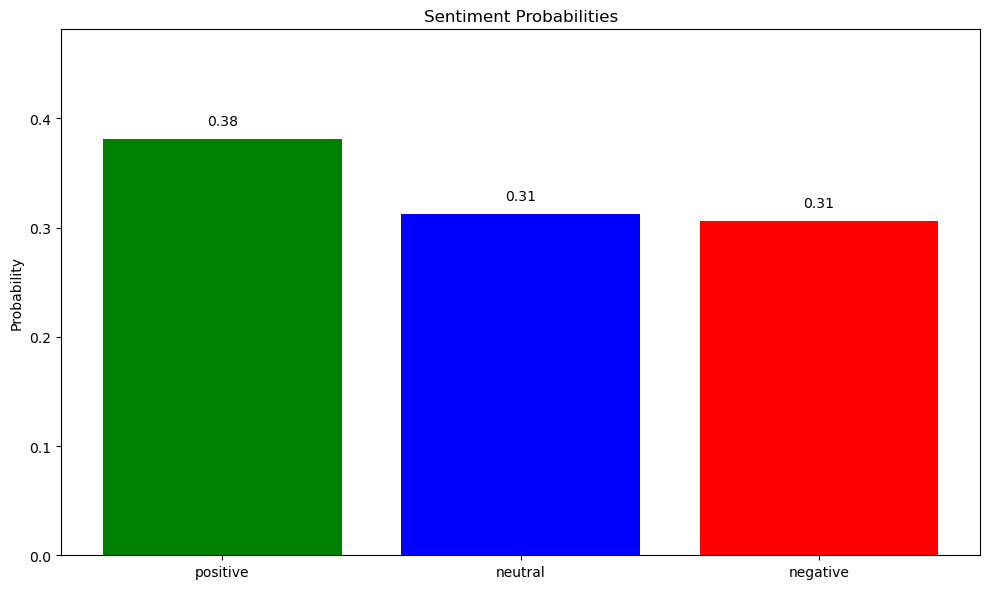

In [10]:
import torch
from transformers import ClapModel, ClapProcessor
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os

def load_clap_model(model_name="laion/clap-htsat-unfused"):
    """Load the CLAP model and processor."""
    model = ClapModel.from_pretrained(model_name)
    processor = ClapProcessor.from_pretrained(model_name)
    return model, processor

def get_audio_embedding(model, processor, audio_data, sampling_rate):
    """Get audio embeddings using CLAP."""
    # Make sure the audio tensor is properly formatted
    if isinstance(audio_data, np.ndarray):
        audio_data = torch.from_numpy(audio_data).float()
    
    # Ensure audio is the right shape
    if audio_data.dim() == 1:
        audio_data = audio_data.unsqueeze(0)
    
    # Normalize audio if needed
    if audio_data.max() > 1.0 or audio_data.min() < -1.0:
        audio_data = audio_data / max(audio_data.max().abs(), audio_data.min().abs())
    
    # Convert back to numpy for processor
    audio_np = audio_data.numpy()
    
    # Process the audio
    audio_inputs = processor(audios=audio_np, sampling_rate=sampling_rate, return_tensors="pt")
    
    # Get audio features
    with torch.no_grad():
        audio_embedding = model.get_audio_features(**audio_inputs)
    
    return audio_embedding.squeeze(0)

def get_text_embeddings(model, processor, sentiment_labels):
    """Get text embeddings for sentiment labels."""
    text_inputs = processor(text=sentiment_labels, return_tensors="pt", padding=True)
    with torch.no_grad():
        text_embeddings = model.get_text_features(**text_inputs)
    return text_embeddings

def predict_sentiment(audio_embedding, text_embeddings, sentiment_labels):
    """Predict sentiment using cosine similarity."""
    cosine_similarities = torch.nn.functional.cosine_similarity(
        audio_embedding.unsqueeze(0), text_embeddings, dim=-1
    )
    
    # Get probabilities
    probabilities = torch.nn.functional.softmax(cosine_similarities, dim=0)
    
    predicted_index = torch.argmax(cosine_similarities).item()
    return sentiment_labels[predicted_index], predicted_index, probabilities.tolist()

def plot_sentiment_probabilities(probabilities, labels):
    """Plot sentiment probabilities as a bar chart."""
    plt.figure(figsize=(10, 6))
    colors = ['green', 'blue', 'red']
    
    bars = plt.bar(labels, probabilities, color=colors)
    
    # Add probability values on top of bars
    for bar, prob in zip(bars, probabilities):
        plt.text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.01, 
                 f'{prob:.2f}', 
                 ha='center', va='bottom')
    
    plt.title('Sentiment Probabilities')
    plt.ylabel('Probability')
    plt.ylim(0, max(probabilities) + 0.1)
    plt.tight_layout()
    plt.show()

def main():
    # Your specific audio path
    audio_path = r"C:\Users\Sumit\Downloads\audio.wav"
    
    # Check if file exists
    if not os.path.exists(audio_path):
        print(f"Error: File '{audio_path}' does not exist!")
        return
        
    # 1. Load model
    print("Loading CLAP model...")
    model, processor = load_clap_model()
    model.eval()
    
    # Get the required sampling rate from the processor
    required_sampling_rate = processor.feature_extractor.sampling_rate
    print(f"Required sampling rate for CLAP model: {required_sampling_rate} Hz")
    
    # Define sentiment labels
    sentiment_labels = ["positive sentiment", "neutral sentiment", "negative sentiment"]
    
    # Get text embeddings for sentiment labels (only need to do this once)
    print("Computing text embeddings for sentiment labels...")
    text_embeddings = get_text_embeddings(model, processor, sentiment_labels)
    
    # 2. Load the audio file using librosa
    print(f"Loading audio from: {audio_path}")
    try:
        # Load audio and resample to the required sampling rate
        audio_data, original_sr = librosa.load(audio_path, sr=None)
        print(f"Original audio: {librosa.get_duration(y=audio_data, sr=original_sr):.2f} seconds, {original_sr} Hz")
        
        # Resample if necessary
        if original_sr != required_sampling_rate:
            print(f"Resampling audio from {original_sr} Hz to {required_sampling_rate} Hz")
            audio_data = librosa.resample(audio_data, orig_sr=original_sr, target_sr=required_sampling_rate)
            print(f"Resampled audio: {librosa.get_duration(y=audio_data, sr=required_sampling_rate):.2f} seconds")
        
    except Exception as e:
        print(f"Error loading audio file: {str(e)}")
        return
    
    # 3. Get audio embedding
    print("Computing audio embedding...")
    audio_embedding = get_audio_embedding(model, processor, audio_data, required_sampling_rate)
    
    # 4. Predict sentiment
    print("Predicting sentiment...")
    predicted_sentiment, pred_idx, probabilities = predict_sentiment(
        audio_embedding, text_embeddings, sentiment_labels
    )
    
    # 5. Display results
    print("\n===== RESULTS =====")
    print(f"Predicted sentiment: {predicted_sentiment}")
    print("\nProbabilities:")
    for label, prob in zip(sentiment_labels, probabilities):
        print(f"  {label}: {prob:.4f}")
    
    # 6. Plot probabilities
    plot_sentiment_probabilities(probabilities, [label.split()[0] for label in sentiment_labels])

if __name__ == "__main__":
    main()

In [ ]:
"C:\Users\Sumit\Downloads\download (1).wav"

Loading CLAP model...
Required sampling rate for CLAP model: 48000 Hz
Computing text embeddings for sentiment labels...
Loading audio from: C:\Users\Sumit\Downloads\download (1).wav
Original audio: 9.36 seconds, 24000 Hz
Resampling audio from 24000 Hz to 48000 Hz
Resampled audio: 9.36 seconds
Computing audio embedding...
Predicting sentiment...

===== RESULTS =====
Predicted sentiment: positive sentiment

Probabilities:
  positive sentiment: 0.3835
  neutral sentiment: 0.3015
  negative sentiment: 0.3150


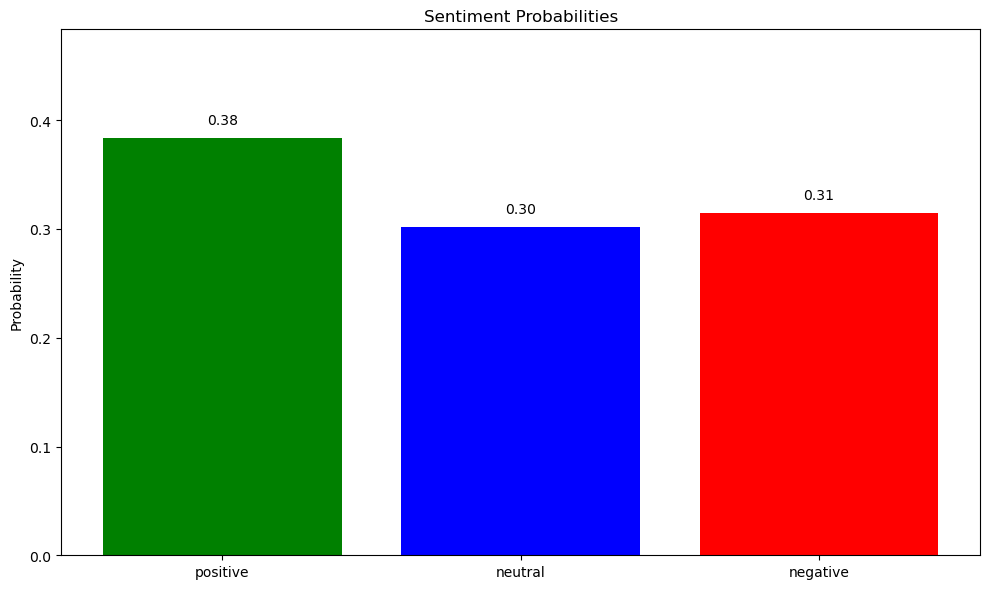

In [12]:
import torch
from transformers import ClapModel, ClapProcessor
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os

def load_clap_model(model_name="laion/clap-htsat-unfused"):
    """Load the CLAP model and processor."""
    model = ClapModel.from_pretrained(model_name)
    processor = ClapProcessor.from_pretrained(model_name)
    return model, processor

def get_audio_embedding(model, processor, audio_data, sampling_rate):
    """Get audio embeddings using CLAP."""
    # Make sure the audio tensor is properly formatted
    if isinstance(audio_data, np.ndarray):
        audio_data = torch.from_numpy(audio_data).float()
    
    # Ensure audio is the right shape
    if audio_data.dim() == 1:
        audio_data = audio_data.unsqueeze(0)
    
    # Normalize audio if needed
    if audio_data.max() > 1.0 or audio_data.min() < -1.0:
        audio_data = audio_data / max(audio_data.max().abs(), audio_data.min().abs())
    
    # Convert back to numpy for processor
    audio_np = audio_data.numpy()
    
    # Process the audio
    audio_inputs = processor(audios=audio_np, sampling_rate=sampling_rate, return_tensors="pt")
    
    # Get audio features
    with torch.no_grad():
        audio_embedding = model.get_audio_features(**audio_inputs)
    
    return audio_embedding.squeeze(0)

def get_text_embeddings(model, processor, sentiment_labels):
    """Get text embeddings for sentiment labels."""
    text_inputs = processor(text=sentiment_labels, return_tensors="pt", padding=True)
    with torch.no_grad():
        text_embeddings = model.get_text_features(**text_inputs)
    return text_embeddings

def predict_sentiment(audio_embedding, text_embeddings, sentiment_labels):
    """Predict sentiment using cosine similarity."""
    cosine_similarities = torch.nn.functional.cosine_similarity(
        audio_embedding.unsqueeze(0), text_embeddings, dim=-1
    )
    
    # Get probabilities
    probabilities = torch.nn.functional.softmax(cosine_similarities, dim=0)
    
    predicted_index = torch.argmax(cosine_similarities).item()
    return sentiment_labels[predicted_index], predicted_index, probabilities.tolist()

def plot_sentiment_probabilities(probabilities, labels):
    """Plot sentiment probabilities as a bar chart."""
    plt.figure(figsize=(10, 6))
    colors = ['green', 'blue', 'red']
    
    bars = plt.bar(labels, probabilities, color=colors)
    
    # Add probability values on top of bars
    for bar, prob in zip(bars, probabilities):
        plt.text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.01, 
                 f'{prob:.2f}', 
                 ha='center', va='bottom')
    
    plt.title('Sentiment Probabilities')
    plt.ylabel('Probability')
    plt.ylim(0, max(probabilities) + 0.1)
    plt.tight_layout()
    plt.show()

def main():
    # Your specific audio path
    audio_path = r"C:\Users\Sumit\Downloads\download (1).wav"
    
    # Check if file exists
    if not os.path.exists(audio_path):
        print(f"Error: File '{audio_path}' does not exist!")
        return
        
    # 1. Load model
    print("Loading CLAP model...")
    model, processor = load_clap_model()
    model.eval()
    
    # Get the required sampling rate from the processor
    required_sampling_rate = processor.feature_extractor.sampling_rate
    print(f"Required sampling rate for CLAP model: {required_sampling_rate} Hz")
    
    # Define sentiment labels
    sentiment_labels = ["positive sentiment", "neutral sentiment", "negative sentiment"]
    
    # Get text embeddings for sentiment labels (only need to do this once)
    print("Computing text embeddings for sentiment labels...")
    text_embeddings = get_text_embeddings(model, processor, sentiment_labels)
    
    # 2. Load the audio file using librosa
    print(f"Loading audio from: {audio_path}")
    try:
        # Load audio and resample to the required sampling rate
        audio_data, original_sr = librosa.load(audio_path, sr=None)
        print(f"Original audio: {librosa.get_duration(y=audio_data, sr=original_sr):.2f} seconds, {original_sr} Hz")
        
        # Resample if necessary
        if original_sr != required_sampling_rate:
            print(f"Resampling audio from {original_sr} Hz to {required_sampling_rate} Hz")
            audio_data = librosa.resample(audio_data, orig_sr=original_sr, target_sr=required_sampling_rate)
            print(f"Resampled audio: {librosa.get_duration(y=audio_data, sr=required_sampling_rate):.2f} seconds")
        
    except Exception as e:
        print(f"Error loading audio file: {str(e)}")
        return
    
    # 3. Get audio embedding
    print("Computing audio embedding...")
    audio_embedding = get_audio_embedding(model, processor, audio_data, required_sampling_rate)
    
    # 4. Predict sentiment
    print("Predicting sentiment...")
    predicted_sentiment, pred_idx, probabilities = predict_sentiment(
        audio_embedding, text_embeddings, sentiment_labels
    )
    
    # 5. Display results
    print("\n===== RESULTS =====")
    print(f"Predicted sentiment: {predicted_sentiment}")
    print("\nProbabilities:")
    for label, prob in zip(sentiment_labels, probabilities):
        print(f"  {label}: {prob:.4f}")
    
    # 6. Plot probabilities
    plot_sentiment_probabilities(probabilities, [label.split()[0] for label in sentiment_labels])

if __name__ == "__main__":
    main()

Enter the path to your audio file:  C:\Users\Sumit\Downloads\download (1).wav


Loading CLAP model...


config.json:   0%|          | 0.00/5.42k [00:00<?, ?B/s]

C:\Users\Sumit\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sumit\.cache\huggingface\hub\models--laion--clap-htsat-fused. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/615M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/614M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Required sampling rate for CLAP model: 48000 Hz
Computing text embeddings for sentiment labels...
Loading audio from: C:\Users\Sumit\Downloads\download (1).wav
Original audio: 9.36 seconds, 24000 Hz
Resampling audio from 24000 Hz to 48000 Hz
Resampled audio: 9.36 seconds
Applying audio enhancement...
Noisereduce not installed. Skipping noise reduction.
Computing audio embedding with segmentation...
Predicting sentiment...

===== RESULTS =====
Predicted sentiment: positive sentiment
Confidence: 0.37

Probabilities:
  positive sentiment: 0.3692 (36.9%) ███████
  neutral sentiment: 0.3641 (36.4%) ███████
  negative sentiment: 0.2667 (26.7%) █████


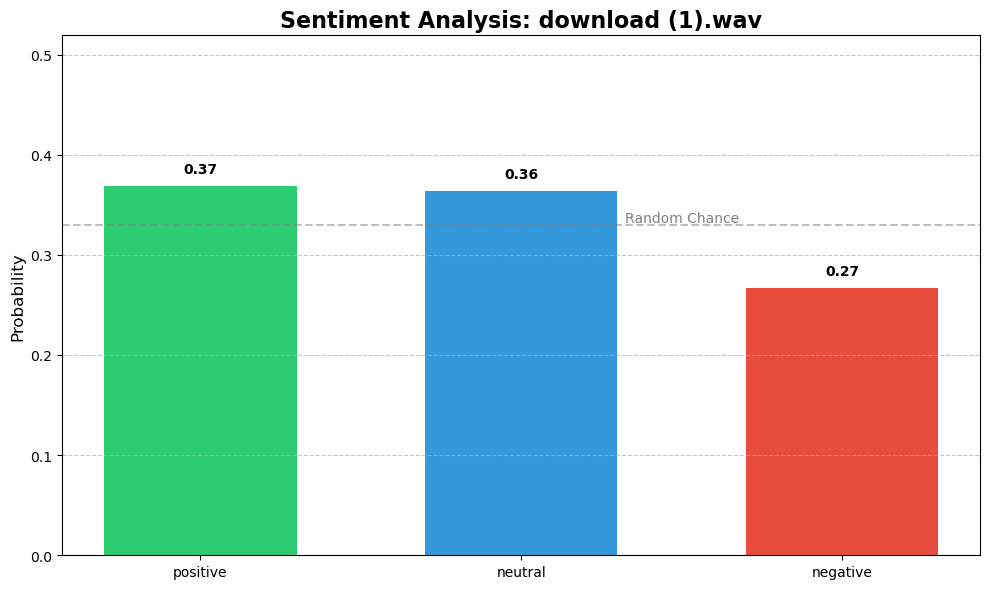


Visualization saved as 'sentiment_results.png'


In [14]:
import torch
from transformers import ClapModel, ClapProcessor
import numpy as np
import matplotlib.pyplot as plt
import librosa
import os
from sklearn.preprocessing import MinMaxScaler
from scipy.special import softmax

def load_clap_model(model_name="laion/clap-htsat-fused"):
    """Load the CLAP model and processor.
    Using the fused model instead of unfused for better performance."""
    model = ClapModel.from_pretrained(model_name)
    processor = ClapProcessor.from_pretrained(model_name)
    return model, processor

def segment_audio(audio_data, sampling_rate, segment_length=10, overlap=0.5):
    """Segment audio into smaller chunks for more robust analysis.
    
    Args:
        audio_data: Audio waveform
        sampling_rate: Audio sampling rate
        segment_length: Length of each segment in seconds
        overlap: Overlap between segments (0-1)
        
    Returns:
        List of audio segments
    """
    # Calculate segment and hop length in samples
    segment_samples = int(segment_length * sampling_rate)
    hop_samples = int(segment_samples * (1 - overlap))
    
    # Get total number of segments
    total_samples = len(audio_data)
    num_segments = max(1, (total_samples - segment_samples) // hop_samples + 1)
    
    segments = []
    for i in range(num_segments):
        start = i * hop_samples
        end = min(start + segment_samples, total_samples)
        
        # If the last segment is too short, pad it
        segment = audio_data[start:end]
        if len(segment) < segment_samples:
            segment = np.pad(segment, (0, segment_samples - len(segment)), 'constant')
        
        segments.append(segment)
    
    # If audio is shorter than segment_length, just return the padded audio
    if not segments:
        padded_audio = np.pad(audio_data, (0, segment_samples - len(audio_data)), 'constant')
        segments = [padded_audio]
        
    return segments

def get_audio_embedding(model, processor, audio_data, sampling_rate, use_segments=True):
    """Get audio embeddings using CLAP with segmentation for robustness."""
    # Make sure the audio tensor is properly formatted
    if isinstance(audio_data, torch.Tensor):
        audio_data = audio_data.numpy()
    
    if use_segments and len(audio_data) > sampling_rate * 5:  # Only segment if > 5 seconds
        # Segment audio into chunks
        segments = segment_audio(audio_data, sampling_rate)
        segment_embeddings = []
        
        for segment in segments:
            # Process the segment
            audio_inputs = processor(audios=segment, sampling_rate=sampling_rate, return_tensors="pt")
            
            # Get segment features
            with torch.no_grad():
                embedding = model.get_audio_features(**audio_inputs)
                segment_embeddings.append(embedding.squeeze(0))
        
        # Average the embeddings from all segments
        audio_embedding = torch.mean(torch.stack(segment_embeddings), dim=0)
    else:
        # Process the whole audio for short clips
        audio_inputs = processor(audios=audio_data, sampling_rate=sampling_rate, return_tensors="pt")
        
        # Get audio features
        with torch.no_grad():
            audio_embedding = model.get_audio_features(**audio_inputs).squeeze(0)
    
    # Normalize the embedding
    audio_embedding = audio_embedding / audio_embedding.norm(dim=-1, keepdim=True)
    return audio_embedding

def get_text_embeddings(model, processor, sentiment_labels, temperature=1.0):
    """Get text embeddings for sentiment labels with better prompts."""
    # Enhanced sentiment prompts with more context
    enhanced_prompts = [
        f"audio with {label}, expressing happiness, joy, satisfaction, or contentment" if "positive" in label else
        f"audio with {label}, expressing neither positive nor negative emotions" if "neutral" in label else
        f"audio with {label}, expressing anger, sadness, frustration, or disappointment"
        for label in sentiment_labels
    ]
    
    text_inputs = processor(text=enhanced_prompts, return_tensors="pt", padding=True)
    
    with torch.no_grad():
        text_embeddings = model.get_text_features(**text_inputs)
        
    # Normalize the embeddings
    text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
    
    return text_embeddings

def predict_sentiment(audio_embedding, text_embeddings, sentiment_labels, temperature=0.5):
    """Predict sentiment using cosine similarity with temperature scaling."""
    # Compute cosine similarity
    cosine_similarities = torch.nn.functional.cosine_similarity(
        audio_embedding.unsqueeze(0), text_embeddings, dim=-1
    )
    
    # Apply temperature scaling to control the confidence
    scaled_similarities = cosine_similarities / temperature
    
    # Get probabilities
    probabilities = torch.nn.functional.softmax(scaled_similarities, dim=0)
    
    # Get prediction
    predicted_index = torch.argmax(probabilities).item()
    confidence = probabilities[predicted_index].item()
    
    return sentiment_labels[predicted_index], predicted_index, probabilities.tolist(), confidence

def plot_sentiment_probabilities(probabilities, labels, title="Sentiment Analysis Results"):
    """Plot sentiment probabilities as a bar chart with improved styling."""
    plt.figure(figsize=(10, 6))
    
    # Use distinct colors with semantic meaning
    colors = ['#2ecc71', '#3498db', '#e74c3c']  # Green for positive, blue for neutral, red for negative
    
    bars = plt.bar(labels, probabilities, color=colors, width=0.6)
    
    # Add probability values on top of bars
    for bar, prob in zip(bars, probabilities):
        plt.text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.01, 
                 f'{prob:.2f}', 
                 ha='center', va='bottom', fontweight='bold')
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.ylabel('Probability', fontsize=12)
    plt.ylim(0, max(probabilities) + 0.15)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Add a threshold line for better interpretation
    plt.axhline(y=0.33, color='gray', linestyle='--', alpha=0.5)  # Random chance threshold
    plt.text(len(labels)/2, 0.33, 'Random Chance', ha='center', va='bottom', color='gray')
    
    return plt

def enhance_audio(audio_data, sampling_rate):
    """Apply audio enhancement preprocessing for better sentiment analysis."""
    # 1. Noise reduction using spectral gating
    try:
        import noisereduce as nr
        audio_data = nr.reduce_noise(y=audio_data, sr=sampling_rate)
    except ImportError:
        print("Noisereduce not installed. Skipping noise reduction.")
    
    # 2. Normalization
    audio_data = librosa.util.normalize(audio_data)
    
    # 3. Trim silence
    audio_data, _ = librosa.effects.trim(audio_data, top_db=20)
    
    return audio_data

def main():
    # Your specific audio path
    audio_path = input("Enter the path to your audio file: ")
    
    # Check if file exists
    if not os.path.exists(audio_path):
        print(f"Error: File '{audio_path}' does not exist!")
        return
        
    # 1. Load model - using the fused model instead of unfused
    print("Loading CLAP model...")
    model, processor = load_clap_model("laion/clap-htsat-fused")
    model.eval()
    
    # Get the required sampling rate from the processor
    required_sampling_rate = processor.feature_extractor.sampling_rate
    print(f"Required sampling rate for CLAP model: {required_sampling_rate} Hz")
    
    # Define sentiment labels
    sentiment_labels = ["positive sentiment", "neutral sentiment", "negative sentiment"]
    
    # Get text embeddings for sentiment labels
    print("Computing text embeddings for sentiment labels...")
    text_embeddings = get_text_embeddings(model, processor, sentiment_labels)
    
    # 2. Load the audio file using librosa
    print(f"Loading audio from: {audio_path}")
    try:
        # Load audio and resample to the required sampling rate
        audio_data, original_sr = librosa.load(audio_path, sr=None)
        print(f"Original audio: {librosa.get_duration(y=audio_data, sr=original_sr):.2f} seconds, {original_sr} Hz")
        
        # Resample if necessary
        if original_sr != required_sampling_rate:
            print(f"Resampling audio from {original_sr} Hz to {required_sampling_rate} Hz")
            audio_data = librosa.resample(audio_data, orig_sr=original_sr, target_sr=required_sampling_rate)
            print(f"Resampled audio: {librosa.get_duration(y=audio_data, sr=required_sampling_rate):.2f} seconds")
        
        # Enhance audio
        print("Applying audio enhancement...")
        audio_data = enhance_audio(audio_data, required_sampling_rate)
        
    except Exception as e:
        print(f"Error loading/processing audio file: {str(e)}")
        return
    
    # 3. Get audio embedding with segmentation
    print("Computing audio embedding with segmentation...")
    audio_embedding = get_audio_embedding(model, processor, audio_data, required_sampling_rate, use_segments=True)
    
    # 4. Predict sentiment with temperature scaling
    print("Predicting sentiment...")
    predicted_sentiment, pred_idx, probabilities, confidence = predict_sentiment(
        audio_embedding, text_embeddings, sentiment_labels, temperature=0.5
    )
    
    # 5. Display results
    print("\n===== RESULTS =====")
    print(f"Predicted sentiment: {predicted_sentiment}")
    print(f"Confidence: {confidence:.2f}")
    print("\nProbabilities:")
    for label, prob in zip(sentiment_labels, probabilities):
        prob_percent = prob * 100
        bar_length = int(prob_percent / 5)
        bar = '█' * bar_length
        print(f"  {label}: {prob:.4f} ({prob_percent:.1f}%) {bar}")
    
    # 6. Plot probabilities
    plt = plot_sentiment_probabilities(
        probabilities, 
        [label.split()[0] for label in sentiment_labels], 
        title=f"Sentiment Analysis: {os.path.basename(audio_path)}"
    )
    plt.savefig('sentiment_results.png')
    plt.show()
    print("\nVisualization saved as 'sentiment_results.png'")

if __name__ == "__main__":
    main()

In [21]:
# Required imports
import torch
from transformers import Wav2Vec2FeatureExtractor, AutoModelForAudioClassification
import librosa
import numpy as np
import os
import mimetypes
from PIL import Image
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Load pre-trained model and feature extractor separately (instead of using AutoProcessor)
try:
    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition")
    model = AutoModelForAudioClassification.from_pretrained("ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition")
    print("Model and feature extractor loaded successfully")
except Exception as e:
    print(f"Error loading model: {str(e)}")
    print("Trying alternative approach...")
    
    # Try an alternative approach using a different model
    try:
        from transformers import pipeline
        emotion_classifier = pipeline("audio-classification", model="superb/wav2vec2-base-superb-er")
        print("Alternative model loaded successfully")
    except Exception as e2:
        print(f"Error loading alternative model: {str(e2)}")

# Function to check file type
def check_file_type(file_path):
    mime_type, _ = mimetypes.guess_type(file_path)
    if mime_type:
        file_type = mime_type.split('/')[0]
        return file_type
    else:
        extension = os.path.splitext(file_path)[1].lower()
        if extension in ['.wav', '.mp3', '.flac', '.ogg']:
            return 'audio'
        elif extension in ['.jpg', '.jpeg', '.png', '.bmp', '.gif']:
            return 'image'
        else:
            return 'unknown'

# Function to predict emotion from an audio file using the feature extractor and model
def predict_emotion_using_model(audio_path, model, feature_extractor):
    try:
        # Load audio
        waveform, sr = librosa.load(audio_path, sr=16000)
        
        # Convert to mono if stereo
        if len(waveform.shape) > 1:
            waveform = librosa.to_mono(waveform)
        
        # Process the audio
        inputs = feature_extractor(waveform, sampling_rate=16000, return_tensors="pt", padding=True)
        
        # Make prediction
        with torch.no_grad():
            logits = model(**inputs).logits
        
        # Get prediction
        predictions = torch.nn.functional.softmax(logits, dim=1)
        predicted_class = torch.argmax(predictions, dim=1).item()
        
        # Define emotion labels (based on the original model's labels)
        emotions = ["angry", "happy", "sad", "neutral", "fearful", "disgust", "surprised"]
        return emotions[predicted_class], predictions[0].tolist()
    except Exception as e:
        return f"Error processing audio: {str(e)}", None

# Function to predict emotion using pipeline (alternative approach)
def predict_emotion_using_pipeline(audio_path, classifier):
    try:
        # Get predictions
        predictions = classifier(audio_path)
        top_prediction = predictions[0]
        return top_prediction["label"], [p["score"] for p in predictions]
    except Exception as e:
        return f"Error processing audio: {str(e)}", None

# Main function to process a file
def process_file(file_path):
    # Check if file exists
    if not os.path.exists(file_path):
        return f"Error: File {file_path} does not exist."
    
    # Check file type
    file_type = check_file_type(file_path)
    
    if file_type == 'audio':
        # Try the first method if available
        if 'model' in globals() and 'feature_extractor' in globals():
            emotion, confidence_scores = predict_emotion_using_model(file_path, model, feature_extractor)
        # Otherwise try the alternative method
        elif 'emotion_classifier' in globals():
            emotion, confidence_scores = predict_emotion_using_pipeline(file_path, emotion_classifier)
        else:
            return "Error: No emotion recognition model could be loaded."
            
        if isinstance(emotion, str) and not emotion.startswith("Error"):
            return {
                "predicted_emotion": emotion,
                "confidence_scores": confidence_scores,
                "file_type": "audio"
            }
        else:
            return emotion  # This will be the error message
    elif file_type == 'image':
        return {
            "error": "The file provided is an image, but this model requires audio input for emotion recognition.",
            "file_type": "image",
            "recommendation": "Please provide an audio file containing speech with emotional content."
        }
    else:
        return {
            "error": f"Unsupported file type: {file_type}",
            "recommendation": "Please provide an audio file (WAV, MP3, etc.) containing speech with emotional content."
        }

# Process the specific file path provided
file_path = r"C:\Users\Sumit\Downloads\download (1).wav"
print(f"Processing file: {file_path}")
result = process_file(file_path)
print(result)

# How to test with an actual audio file:
"""
# Example: Run with an actual audio file
test_audio_path = "path/to/your/audio_file.wav"  # Replace with your actual audio file path
if os.path.exists(test_audio_path):
    result = process_file(test_audio_path)
    print(f"Result for audio file: {result}")
"""

Some weights of the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition were not used when initializing Wav2Vec2ForSequenceClassification: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.output.bias', 'classifier.output.weight']
- This IS expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition and are newly initialized: ['classifier.bias', 'classifier.weight', '

Model and feature extractor loaded successfully
Processing file: C:\Users\Sumit\Downloads\download (1).wav
{'predicted_emotion': 'fearful', 'confidence_scores': [0.1261843591928482, 0.12507861852645874, 0.12542621791362762, 0.11409679800271988, 0.13137362897396088, 0.1225091740489006, 0.13041119277477264, 0.12492001801729202], 'file_type': 'audio'}


'\n# Example: Run with an actual audio file\ntest_audio_path = "path/to/your/audio_file.wav"  # Replace with your actual audio file path\nif os.path.exists(test_audio_path):\n    result = process_file(test_audio_path)\n    print(f"Result for audio file: {result}")\n'

In [23]:
# Required imports
import torch
from transformers import Wav2Vec2FeatureExtractor, AutoModelForAudioClassification
import librosa
import numpy as np
import os
import mimetypes
import warnings
from sklearn.metrics.pairwise import cosine_similarity

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Load pre-trained model and feature extractor separately
try:
    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition")
    model = AutoModelForAudioClassification.from_pretrained("ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition")
    print("Model and feature extractor loaded successfully")
    model_loaded = True
except Exception as e:
    print(f"Error loading primary model: {str(e)}")
    model_loaded = False
    
    # Try an alternative approach using a different model
    try:
        from transformers import pipeline
        emotion_classifier = pipeline("audio-classification", model="superb/wav2vec2-base-superb-er")
        print("Alternative model loaded successfully")
        alt_model_loaded = True
    except Exception as e2:
        print(f"Error loading alternative model: {str(e2)}")
        alt_model_loaded = False

# Function to extract embeddings from audio for one-shot learning
def extract_embeddings(audio_path, model, feature_extractor):
    try:
        # Load audio
        waveform, sr = librosa.load(audio_path, sr=16000)
        
        # Convert to mono if stereo
        if len(waveform.shape) > 1:
            waveform = librosa.to_mono(waveform)
        
        # Process the audio
        inputs = feature_extractor(waveform, sampling_rate=16000, return_tensors="pt", padding=True)
        
        # Extract hidden states (embeddings)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            # Get the last hidden state as embedding
            embedding = outputs.hidden_states[-1].mean(dim=1).squeeze().numpy()
            
        return embedding
    except Exception as e:
        print(f"Error extracting embeddings: {str(e)}")
        return None

# Function to implement one-shot learning
def one_shot_emotion_recognition(target_audio_path, reference_examples=None):
    """
    Performs one-shot emotion recognition by comparing target audio with reference examples.
    If no reference examples are provided, falls back to standard classification.
    
    Args:
        target_audio_path: Path to the audio file to classify
        reference_examples: Dictionary of {emotion: audio_path} for reference samples
    """
    if not os.path.exists(target_audio_path):
        return f"Error: Target audio file {target_audio_path} does not exist."
    
    # If no reference examples or model not loaded, fall back to standard classification
    if reference_examples is None or not model_loaded:
        return standard_emotion_classification(target_audio_path)
    
    # Extract target embedding
    target_embedding = extract_embeddings(target_audio_path, model, feature_extractor)
    if target_embedding is None:
        return "Error extracting embedding from target audio."
    
    # Extract embeddings for reference examples
    similarities = {}
    for emotion, audio_path in reference_examples.items():
        if os.path.exists(audio_path):
            ref_embedding = extract_embeddings(audio_path, model, feature_extractor)
            if ref_embedding is not None:
                # Calculate cosine similarity
                sim = cosine_similarity([target_embedding], [ref_embedding])[0][0]
                similarities[emotion] = sim
            else:
                print(f"Warning: Could not extract embedding for {emotion} reference")
        else:
            print(f"Warning: Reference audio for {emotion} does not exist at {audio_path}")
    
    if not similarities:
        print("No valid reference embeddings extracted, falling back to standard classification")
        return standard_emotion_classification(target_audio_path)
    
    # Find the most similar emotion
    best_emotion = max(similarities.items(), key=lambda x: x[1])
    
    return {
        "method": "one-shot",
        "predicted_emotion": best_emotion[0],
        "similarities": similarities,
        "confidence": best_emotion[1]
    }

# Standard classification function (fallback)
def standard_emotion_classification(audio_path):
    """Standard emotion classification using pre-trained model"""
    
    # Check file type
    mime_type, _ = mimetypes.guess_type(audio_path)
    if mime_type and not mime_type.startswith('audio'):
        return {
            "error": f"The file provided is not an audio file, but {mime_type}.",
            "recommendation": "Please provide an audio file containing speech with emotional content."
        }
    
    # Try the first model if available
    if model_loaded:
        try:
            # Load audio
            waveform, sr = librosa.load(audio_path, sr=16000)
            
            # Convert to mono if stereo
            if len(waveform.shape) > 1:
                waveform = librosa.to_mono(waveform)
            
            # Process the audio
            inputs = feature_extractor(waveform, sampling_rate=16000, return_tensors="pt", padding=True)
            
            # Make prediction
            with torch.no_grad():
                logits = model(**inputs).logits
            
            # Get prediction
            predictions = torch.nn.functional.softmax(logits, dim=1)
            predicted_class = torch.argmax(predictions, dim=1).item()
            
            # Define emotion labels (based on the original model's labels)
            emotions = ["angry", "happy", "sad", "neutral", "fearful", "disgust", "surprised"]
            return {
                "method": "standard-classification",
                "predicted_emotion": emotions[predicted_class],
                "confidence_scores": predictions[0].tolist(),
                "file_type": "audio"
            }
        except Exception as e:
            print(f"Error in standard classification (primary model): {str(e)}")
            pass
    
    # If first model failed, try alternative method
    if 'emotion_classifier' in globals():
        try:
            # Get predictions
            predictions = emotion_classifier(audio_path)
            top_prediction = predictions[0]
            return {
                "method": "alternative-model",
                "predicted_emotion": top_prediction["label"],
                "confidence_scores": [p["score"] for p in predictions],
                "file_type": "audio"
            }
        except Exception as e:
            return f"Error processing audio with alternative model: {str(e)}"
    
    return "Error: No emotion recognition model could be loaded or used successfully."

# Example reference examples (you would need to replace these with actual paths)
# These should be representative samples of each emotion you want to detect
reference_examples = {
    "happy": r"C:\path\to\happy_reference.wav",  # Replace with actual path
    "sad": r"C:\path\to\sad_reference.wav",      # Replace with actual path
    "angry": r"C:\path\to\angry_reference.wav",  # Replace with actual path
    "neutral": r"C:\path\to\neutral_reference.wav"  # Replace with actual path
}

# Process your audio file
target_audio_path = r"C:\Users\Sumit\Downloads\download (1).wav"
print(f"Processing file: {target_audio_path}")

# First try one-shot recognition if you have reference examples
# Comment out this conditional to use the one-shot method with your reference examples
if os.path.exists(reference_examples.get("happy", "")) and os.path.exists(reference_examples.get("sad", "")):
    result = one_shot_emotion_recognition(target_audio_path, reference_examples)
else:
    # Otherwise fall back to standard classification
    print("No valid reference examples found, using standard classification")
    result = standard_emotion_classification(target_audio_path)

print(result)

"""
# How to use:

# 1. For standard classification (no examples needed):
result = standard_emotion_classification("path/to/your/audio.wav")

# 2. For one-shot learning (with examples):
references = {
    "happy": "path/to/happy_example.wav",
    "sad": "path/to/sad_example.wav",
    # Add more emotions as needed
}
result = one_shot_emotion_recognition("path/to/target_audio.wav", references)
"""

Some weights of the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition were not used when initializing Wav2Vec2ForSequenceClassification: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.output.bias', 'classifier.output.weight']
- This IS expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition and are newly initialized: ['classifier.bias', 'classifier.weight', '

Model and feature extractor loaded successfully
Processing file: C:\Users\Sumit\Downloads\download (1).wav
No valid reference examples found, using standard classification
{'method': 'standard-classification', 'predicted_emotion': 'disgust', 'confidence_scores': [0.12349420040845871, 0.12706466019153595, 0.12630042433738708, 0.12378903478384018, 0.12185389548540115, 0.12770149111747742, 0.12318747490644455, 0.126608744263649], 'file_type': 'audio'}


'\n# How to use:\n\n# 1. For standard classification (no examples needed):\nresult = standard_emotion_classification("path/to/your/audio.wav")\n\n# 2. For one-shot learning (with examples):\nreferences = {\n    "happy": "path/to/happy_example.wav",\n    "sad": "path/to/sad_example.wav",\n    # Add more emotions as needed\n}\nresult = one_shot_emotion_recognition("path/to/target_audio.wav", references)\n'

In [27]:
import torch
import librosa
import numpy as np
import os
import warnings
from transformers import pipeline
from sklearn.metrics.pairwise import cosine_similarity

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

class SpeechEmotionRecognizer:
    def __init__(self):
        self.models = {}
        self.feature_extractors = {}
        self.available_models = self._load_models()
        
    def _load_models(self):
        """Load available models for speech emotion recognition"""
        available_models = {}
        
        # Try loading the primary model
        try:
            from transformers import AutoFeatureExtractor, AutoModelForAudioClassification
            model_name = "ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition"
            
            self.feature_extractors["primary"] = AutoFeatureExtractor.from_pretrained(model_name)
            self.models["primary"] = AutoModelForAudioClassification.from_pretrained(model_name)
            
            # Define emotion labels for this model
            available_models["primary"] = {
                "name": "XLSR Wav2Vec2 (ehcalabres)",
                "emotions": ["angry", "happy", "sad", "neutral", "fearful", "disgust", "surprised"]
            }
            print("Primary model loaded successfully")
        except Exception as e:
            print(f"Could not load primary model: {str(e)}")
        
        # Try loading alternative model
        try:
            self.models["alternative"] = pipeline(
                "audio-classification", 
                model="superb/wav2vec2-base-superb-er"
            )
            available_models["alternative"] = {
                "name": "SuperB Wav2Vec2",
                "emotions": ["neu", "hap", "ang", "sad"]  # These are the labels used by this model
            }
            print("Alternative model loaded successfully")
        except Exception as e:
            print(f"Could not load alternative model: {str(e)}")
            
        # Try loading a third option if needed
        try:
            self.models["hubert"] = pipeline(
                "audio-classification", 
                model="facebook/hubert-large-ls960-ft"
            )
            available_models["hubert"] = {
                "name": "HuBERT",
                "emotions": ["neutral", "happy", "angry", "sad", "fearful", "disgust", "surprised"]
            }
            print("HuBERT model loaded successfully")
        except Exception as e:
            print(f"Could not load HuBERT model: {str(e)}")
        
        return available_models
    
    def extract_embeddings(self, audio_path, model_key="primary"):
        """Extract embeddings from audio for one-shot learning"""
        if model_key not in self.models or model_key not in self.feature_extractors:
            return None
            
        try:
            # Load audio
            waveform, sr = librosa.load(audio_path, sr=16000)
            
            # Convert to mono if stereo
            if len(waveform.shape) > 1:
                waveform = librosa.to_mono(waveform)
            
            # Process the audio
            inputs = self.feature_extractors[model_key](
                waveform, 
                sampling_rate=16000, 
                return_tensors="pt", 
                padding=True
            )
            
            # Extract hidden states (embeddings)
            with torch.no_grad():
                outputs = self.models[model_key](**inputs, output_hidden_states=True)
                # Get the last hidden state as embedding
                embedding = outputs.hidden_states[-1].mean(dim=1).squeeze().numpy()
                
            return embedding
        except Exception as e:
            print(f"Error extracting embeddings: {str(e)}")
            return None
    
    def one_shot_emotion_recognition(self, target_audio_path, reference_examples, model_key="primary"):
        """
        One-shot emotion recognition comparing target audio with reference examples.
        
        Args:
            target_audio_path: Path to the audio file to classify
            reference_examples: Dictionary of {emotion: audio_path} for reference samples
            model_key: Which model to use for embedding extraction
        """
        if not os.path.exists(target_audio_path):
            return {"error": f"Target audio file {target_audio_path} does not exist."}
        
        # Check if model is available
        if model_key not in self.models or model_key not in self.feature_extractors:
            return {"error": f"Model {model_key} not available. Try another model."}
        
        # Validate reference examples
        valid_references = {}
        for emotion, path in reference_examples.items():
            if os.path.exists(path):
                valid_references[emotion] = path
        
        if not valid_references:
            print("No valid reference examples found, falling back to standard classification")
            return self.classify_emotion(target_audio_path)
        
        # Extract target embedding
        target_embedding = self.extract_embeddings(target_audio_path, model_key)
        if target_embedding is None:
            return {"error": "Error extracting embedding from target audio."}
        
        # Extract embeddings for reference examples
        similarities = {}
        for emotion, audio_path in valid_references.items():
            ref_embedding = self.extract_embeddings(audio_path, model_key)
            if ref_embedding is not None:
                # Calculate cosine similarity
                sim = cosine_similarity([target_embedding], [ref_embedding])[0][0]
                similarities[emotion] = sim
            else:
                print(f"Warning: Could not extract embedding for {emotion} reference")
        
        if not similarities:
            print("No valid reference embeddings extracted, falling back to standard classification")
            return self.classify_emotion(target_audio_path)
        
        # Find the most similar emotion
        best_emotion = max(similarities.items(), key=lambda x: x[1])
        
        return {
            "method": "one-shot",
            "model": self.available_models[model_key]["name"],
            "predicted_emotion": best_emotion[0],
            "confidence": best_emotion[1],
            "all_similarities": similarities
        }
    
    def classify_emotion(self, audio_path, model_key=None):
        """
        Standard emotion classification using pre-trained models
        
        Args:
            audio_path: Path to the audio file to classify
            model_key: Which model to use. If None, tries all available models.
        """
        if not os.path.exists(audio_path):
            return {"error": f"Audio file {audio_path} does not exist."}
            
        # If no specific model requested, try all available models
        if model_key is None:
            results = {}
            for key in self.models.keys():
                try:
                    result = self._classify_with_model(audio_path, key)
                    results[key] = result
                except Exception as e:
                    results[key] = {"error": str(e)}
            
            # Return the best result (based on confidence)
            if results:
                # Try to find a result with highest confidence
                best_result = None
                best_confidence = -1
                
                for model_name, result in results.items():
                    if "error" not in result and "confidence" in result and result["confidence"] > best_confidence:
                        best_confidence = result["confidence"]
                        best_result = result
                
                if best_result:
                    return best_result
                else:
                    return {"results": results, "error": "No model produced confident results"}
            else:
                return {"error": "No models available for classification"}
        else:
            # Use the specified model
            if model_key in self.models:
                return self._classify_with_model(audio_path, model_key)
            else:
                return {"error": f"Model {model_key} not available"}
    
    def _classify_with_model(self, audio_path, model_key):
        """Internal method to classify with a specific model"""
        if model_key == "primary":
            return self._classify_with_primary(audio_path)
        elif model_key in ["alternative", "hubert"]:
            return self._classify_with_pipeline(audio_path, model_key)
        else:
            return {"error": f"Unknown model key: {model_key}"}
    
    def _classify_with_primary(self, audio_path):
        """Classify using the primary model"""
        try:
            # Load audio
            waveform, sr = librosa.load(audio_path, sr=16000)
            
            # Convert to mono if stereo
            if len(waveform.shape) > 1:
                waveform = librosa.to_mono(waveform)
            
            # Process the audio
            inputs = self.feature_extractors["primary"](
                waveform, 
                sampling_rate=16000, 
                return_tensors="pt", 
                padding=True
            )
            
            # Make prediction
            with torch.no_grad():
                outputs = self.models["primary"](**inputs)
                logits = outputs.logits
            
            # Get prediction
            predictions = torch.nn.functional.softmax(logits, dim=1)[0]
            predicted_class = torch.argmax(predictions, dim=0).item()
            
            # Get the emotion labels
            emotions = self.available_models["primary"]["emotions"]
            
            # Calculate confidence (max probability)
            confidence = predictions[predicted_class].item()
            
            # Format the results with all emotion probabilities
            emotion_probs = {emotions[i]: predictions[i].item() for i in range(len(emotions))}
            
            return {
                "method": "standard-classification",
                "model": self.available_models["primary"]["name"],
                "predicted_emotion": emotions[predicted_class],
                "confidence": confidence,
                "all_emotions": emotion_probs
            }
        except Exception as e:
            return {"error": f"Error in primary model classification: {str(e)}"}
    
    def _classify_with_pipeline(self, audio_path, model_key):
        """Classify using a pipeline model"""
        try:
            # Get predictions
            predictions = self.models[model_key](audio_path)
            
            # Get the top prediction
            top_prediction = predictions[0]
            
            # Format the results
            emotion_probs = {pred["label"]: pred["score"] for pred in predictions}
            
            return {
                "method": "pipeline-classification",
                "model": self.available_models[model_key]["name"],
                "predicted_emotion": top_prediction["label"],
                "confidence": top_prediction["score"],
                "all_emotions": emotion_probs
            }
        except Exception as e:
            return {"error": f"Error in {model_key} model classification: {str(e)}"}
    
    def list_available_models(self):
        """List all available models for emotion recognition"""
        return self.available_models


# Example usage
def main():
    recognizer = SpeechEmotionRecognizer()
    
    # Print available models
    print("Available models:")
    for key, model_info in recognizer.list_available_models().items():
        print(f"  - {key}: {model_info['name']} (Emotions: {', '.join(model_info['emotions'])})")
    
    # Example file path - replace with your audio file
    
    audio_path = r"C:\Users\Sumit\Downloads\download (1).wav"

    
    # For standard classification (using all available models)
    if os.path.exists(audio_path):
        print(f"\nProcessing file: {audio_path}")
        result = recognizer.classify_emotion(audio_path)
        print("Standard classification result:")
        print(result)
    else:
        print(f"\nAudio file not found: {audio_path}")
        print("Please provide a valid audio file path to test the classification")
    
    # For one-shot learning with examples (if you have reference examples)
    """
    references = {
        "happy": "path/to/happy_example.wav",
        "sad": "path/to/sad_example.wav",
        "angry": "path/to/angry_example.wav",
        "neutral": "path/to/neutral_example.wav"
    }
    
    # Check if reference files exist
    valid_references = {emotion: path for emotion, path in references.items() if os.path.exists(path)}
    
    if valid_references and os.path.exists(audio_path):
        one_shot_result = recognizer.one_shot_emotion_recognition(audio_path, valid_references)
        print("\nOne-shot recognition result:")
        print(one_shot_result)
    else:
        print("\nCannot perform one-shot learning: missing reference files or target audio")
    """


if __name__ == "__main__":
    main()

Some weights of the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition were not used when initializing Wav2Vec2ForSequenceClassification: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.output.bias', 'classifier.output.weight']
- This IS expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at ehcalabres/wav2vec2-lg-xlsr-en-speech-emotion-recognition and are newly initialized: ['classifier.bias', 'classifier.weight', '

Primary model loaded successfully


config.json:   0%|          | 0.00/2.15k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Device set to use cpu


HuBERT model loaded successfully
Available models:
  - primary: XLSR Wav2Vec2 (ehcalabres) (Emotions: angry, happy, sad, neutral, fearful, disgust, surprised)
  - alternative: SuperB Wav2Vec2 (Emotions: neu, hap, ang, sad)
  - hubert: HuBERT (Emotions: neutral, happy, angry, sad, fearful, disgust, surprised)

Processing file: C:\Users\Sumit\Downloads\download (1).wav


model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Standard classification result:
{'method': 'standard-classification', 'model': 'XLSR Wav2Vec2 (ehcalabres)', 'predicted_emotion': 'fearful', 'confidence': 0.13190299272537231, 'all_emotions': {'angry': 0.11971762776374817, 'happy': 0.1280404031276703, 'sad': 0.1246904507279396, 'neutral': 0.1253417730331421, 'fearful': 0.13190299272537231, 'disgust': 0.12279409915208817, 'surprised': 0.12375006824731827}}


In [29]:
from transformers.utils import logging
logging.set_verbosity_error()
from datasets import load_dataset, Audio
from transformers import pipeline
from IPython.display import Audio as IPythonAudio

# Load the dataset directly from Hugging Face instead of from disk
# Using the first 10 samples for faster processing
dataset = load_dataset("ashraq/esc50", split="train[0:10]")

# Cast the audio column to ensure correct sampling rate (48kHz)
dataset = dataset.cast_column("audio", Audio(sampling_rate=48_000))

# Get an audio sample
audio_sample = dataset[0]

# Display basic audio information
print(f"Sample audio duration: {len(audio_sample['audio']['array']) / audio_sample['audio']['sampling_rate']} seconds")
print(f"Sample audio sampling rate: {audio_sample['audio']['sampling_rate']} Hz")

# Play the audio (in notebook environments)
IPythonAudio(audio_sample["audio"]["array"], rate=audio_sample["audio"]["sampling_rate"])

# Load the zero-shot audio classification model
# Assuming the model is available locally, otherwise we'll download it from HF
try:
    zero_shot_classifier = pipeline(
        task="zero-shot-audio-classification",
        model="./models/laion/clap-htsat-unfused"
    )
except FileNotFoundError:
    print("Local model not found, downloading from Hugging Face...")
    zero_shot_classifier = pipeline(
        task="zero-shot-audio-classification",
        model="laion/clap-htsat-unfused"
    )

# Check the model's expected sampling rate
print(f"Model expected sampling rate: {zero_shot_classifier.feature_extractor.sampling_rate} Hz")

# Define sentiment labels for classification
sentiment_labels = ["Positive sound", "Negative sound", "Neutral sound"]

# Run sentiment classification
sentiment_results = zero_shot_classifier(
    audio_sample["audio"]["array"],
    candidate_labels=sentiment_labels
)

# Print results
print("\nSentiment Classification Results:")
for result in sentiment_results:
    print(f"{result['label']}: {result['score']:.4f}")

# You can process multiple samples from the dataset
print("\nProcessing multiple samples:")
for i in range(min(5, len(dataset))):
    sample = dataset[i]
    results = zero_shot_classifier(
        sample["audio"]["array"],
        candidate_labels=sentiment_labels
    )
    print(f"\nSample {i} ({sample.get('filename', 'unknown')})")
    for result in results:
        print(f"{result['label']}: {result['score']:.4f}")

# Alternative with more specific sentiment labels
specific_sentiment_labels = [
    "Sound of laughter or joy", 
    "Sound of crying or distress",
    "Sound of calm background noise", 
    "Sound of excitement or celebration",
    "Sound of anger or frustration"
]

# Classify using more specific sentiment labels
print("\nClassification with specific sentiment labels:")
specific_results = zero_shot_classifier(
    audio_sample["audio"]["array"],
    candidate_labels=specific_sentiment_labels
)

for result in specific_results:
    print(f"{result['label']}: {result['score']:.4f}")

# Map specific emotions to sentiment categories
def map_to_sentiment(specific_results):
    positive_labels = ["Sound of laughter or joy", "Sound of excitement or celebration"]
    negative_labels = ["Sound of crying or distress", "Sound of anger or frustration"]
    neutral_labels = ["Sound of calm background noise"]
    
    # Get the top predicted label
    top_label = specific_results[0]['label']
    
    if top_label in positive_labels:
        return "Positive"
    elif top_label in negative_labels:
        return "Negative"
    else:
        return "Neutral"

print(f"\nMapped sentiment: {map_to_sentiment(specific_results)}")

README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json:   0%|          | 0.00/1.61k [00:00<?, ?B/s]

(…)-00000-of-00002-2f1ab7b824ec751f.parquet:   0%|          | 0.00/387M [00:00<?, ?B/s]

Error while downloading from https://cdn-lfs.hf.co/repos/c5/ae/c5aecbf866a53a1b58d5719fa3b30f8482701c7e6aa9247f51f6b6068bcd6574/01fafd618bad0813b1c844466c35d0aea4ee02aeb0ffcde6e012ca48dcd38dbb?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27train-00000-of-00002-2f1ab7b824ec751f.parquet%3B+filename%3D%22train-00000-of-00002-2f1ab7b824ec751f.parquet%22%3B&Expires=1740468982&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0MDQ2ODk4Mn19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9yZXBvcy9jNS9hZS9jNWFlY2JmODY2YTUzYTFiNThkNTcxOWZhM2IzMGY4NDgyNzAxYzdlNmFhOTI0N2Y1MWY2YjYwNjhiY2Q2NTc0LzAxZmFmZDYxOGJhZDA4MTNiMWM4NDQ0NjZjMzVkMGFlYTRlZTAyYWViMGZmY2RlNmUwMTJjYTQ4ZGNkMzhkYmI%7EcmVzcG9uc2UtY29udGVudC1kaXNwb3NpdGlvbj0qIn1dfQ__&Signature=DKs6f35Q%7ECyX4tNX3EBM8kQWYPqkM39w3t1GPUo-Qkm4uyNXdQUOQNa-8OJ69Cu4DVh6F0k6k4u42aL8Hb5dZfsqtandtr2cO%7E4pyvdw7d3CCBnphd1yUeKtoj%7EB%7EofCIQXSQ4QdIONs6Xat-qWsg29W1mzGiun1Ovdpga5sDnEawwtK1Yx%7E930osM9daHr3xrsKsw8N5

(…)-00000-of-00002-2f1ab7b824ec751f.parquet:  71%|#######   | 273M/387M [00:00<?, ?B/s]

(…)-00001-of-00002-27425e5c1846b494.parquet:   0%|          | 0.00/387M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Sample audio duration: 5.000020833333333 seconds
Sample audio sampling rate: 48000 Hz


OSError: Incorrect path_or_model_id: './models/laion/clap-htsat-unfused'. Please provide either the path to a local folder or the repo_id of a model on the Hub.